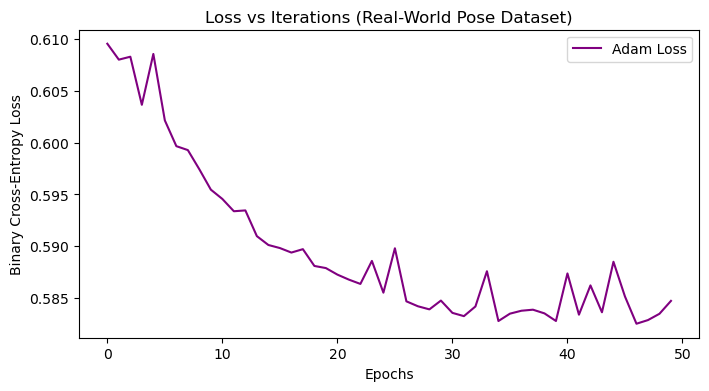

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load Data (if using real dataset)
# df = pd.read_csv('pose_dataset.csv')
# X = df[['f1','f2']].values
# y = df['label'].values.reshape(-1,1)

# --- MOCK DATA FOR TESTING ---
np.random.seed(42)

X_class0 = np.random.randn(50,2) * 0.2 + [0.5,0.5]   # Hands crossed
X_class1 = np.random.randn(50,2) * 0.2 + [1.5,1.5]   # Hands up

X = np.vstack([X_class0, X_class1])
y = np.vstack([np.zeros((50,1)), np.ones((50,1))])


def sigmoid(z):
    return 1/(1+np.exp(-z))


def bce_loss(w, X, y):

    z = np.dot(X, w)
    y_hat = sigmoid(z)

    y_hat = np.clip(y_hat,1e-15,1-1e-15)

    return -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))


def get_gradients(w, X_batch, y_batch):

    y_hat = sigmoid(np.dot(X_batch, w))

    return np.dot(X_batch.T,(y_hat-y_batch))/len(y_batch)


# 2. Mini-Batch Training Loop
def train_logistic_regression(optimizer_name, start_w, X, y, epochs=50, lr=0.1, batch_size=16):

    w = np.array(start_w, dtype=np.float64).reshape(2,1)

    history = []

    # optimizer variables
    v = np.zeros((2,1))
    sq_grad = np.zeros((2,1))
    m = np.zeros((2,1))

    t = 0

    beta1, beta2, epsilon = 0.9, 0.999, 1e-8

    n_samples = X.shape[0]


    for epoch in range(epochs):

        indices = np.random.permutation(n_samples)

        X_shuffled = X[indices]
        y_shuffled = y[indices]


        if optimizer_name == 'GD':
            current_batch_size = n_samples

        elif optimizer_name == 'SGD':
            current_batch_size = 1

        else:
            current_batch_size = batch_size


        for i in range(0, n_samples, current_batch_size):

            X_batch = X_shuffled[i:i+current_batch_size]
            y_batch = y_shuffled[i:i+current_batch_size]

            g = get_gradients(w, X_batch, y_batch)

            t += 1


            if optimizer_name in ['GD','SGD','MBGD']:

                w -= lr*g


            elif optimizer_name == 'Adam':

                m = beta1*m + (1-beta1)*g

                sq_grad = beta2*sq_grad + (1-beta2)*(g**2)

                m_hat = m/(1-beta1**t)
                v_hat = sq_grad/(1-beta2**t)

                w -= (lr/(np.sqrt(v_hat)+epsilon))*m_hat


        loss = bce_loss(w, X, y)

        history.append((w.copy().flatten(), loss))


    return history


# Train and plot (Example for Adam)

history_adam = train_logistic_regression('Adam', [-2.0, 2.0], X, y)

losses = [h[1] for h in history_adam]


plt.figure(figsize=(8,4))

plt.plot(losses, label='Adam Loss', color='purple')

plt.title('Loss vs Iterations (Real-World Pose Dataset)')

plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')

plt.legend()

plt.show()